# Frey and Šešelja (2020) replication


Here we replicate Frey and Šešelja robustness checks. They added a dynamic shift of objective probabilities towards an actual value of 1 for the correct theory and 0 of the correct theory. Thereafter, they checked the performance of the complete graph and the cycle graph in terms of rounds needed to reach consensus on the correct hypothesis in different settings.
We start by importing the packages we need and the model.

In [1]:
import mesa
from mesa.discrete_space import Network, FixedAgent, CellCollection
import networkx as nx
import pandas as pd
import seaborn as sns



###                 AGENTS                  ###
class Scientist(FixedAgent):

    def __init__(self, model, cell, a_objective, b_objective, max_priors, theory_threshold, inertia, step_pulls):
        super().__init__(model)
        self.cell = cell
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.max_priors = max_priors
        self.theory_threshold = theory_threshold
        self.inertia = inertia
        self.inertia_counter = 0
        self.step_pulls = step_pulls

        #Prior beliefs of each agent
        epsilon = .000000000000000000001
        self.priors = {
        "a_alpha": self.random.uniform(epsilon, self.max_priors),
        "a_beta": self.random.uniform(epsilon, self.max_priors),
        "b_alpha": self.random.uniform(epsilon, self.max_priors),
        "b_beta": self.random.uniform(epsilon, self.max_priors)
        }

        #Define whether the agents prefers to pull the A or B lever as it's state
        if self.a_expectations() > self.b_expectations():
            self.state = "a"
        else:
            self.state = "b"
        
        #Define the level of theory threshold of the agent
        if self.theory_threshold == True: 
            self.theory_threshold = 0.1
        else: self.theory_threshold = 0

        self.dynamic_counter = 0
        
        self.experiment_result = (0, 0, 0)
        

    #Funcions for calculating expectations for each hypotheses
    def a_expectations(self):
        a_exp = self.priors["a_alpha"] / (self.priors ["a_alpha"] + self.priors ["a_beta"])
        return a_exp

    def b_expectations(self):
        b_exp = self.priors["b_alpha"] / (self.priors ["b_alpha"] + self.priors ["b_beta"])
        return b_exp
    
    #Research behaviour: performing experiments
    def research(self):

        pull, success, trial = self.experiment_result

        #Choose action based of belief
        if self.state == "a":
            pull = 1
            current_objective_prob = self.a_objective
        else:
            pull = 2
            current_objective_prob = self.b_objective
        
        #Performing experiment (sampling from a binomial distribution)
        success = self.rng.binomial(n=self.step_pulls, p=current_objective_prob)
        
        trial = self.step_pulls

        self.experiment_result = (pull, success, trial)
        
        return self.experiment_result

    #Update behaviour: updating expectations based non experimental results
    def update(self):
        # Update beliefs based on OWN results
        pull, success, trial = self.experiment_result

        if pull == 1:
            self.priors["a_alpha"] += success
            self.priors["a_beta"] += trial - success
        else:
            self.priors["b_alpha"] += success
            self.priors["b_beta"] += trial - success

        #Update beliefs based on NEIGHBORS results
        for neighbor in self.cell.neighborhood.agents: 
            
            pull, success, trial = neighbor.experiment_result

            if pull == 1:
                self.priors["a_alpha"] += success
                self.priors["a_beta"] += trial - success
            else:
                self.priors["b_alpha"] += success
                self.priors["b_beta"] += trial - success
            
        #Updating preferences for experimentations (include theory_threshold and inertia)    
        if self.state == "a":
            if (self.a_expectations() + self.theory_threshold) > self.b_expectations():
                self.state = "a"
                self.inertia_counter = 0
            else:
                self.inertia_counter += 1
                if self.inertia_counter >= self.inertia:
                    self.state = "b"
        
        else:
            if (self.b_expectations() + self.theory_threshold) > self.a_expectations():
                self.state = "b"
                self.inertia_counter = 0
            else:
                self.inertia_counter += 1
                if self.inertia_counter >= self.inertia:
                    self.state = "a"
    
    def update_objectives(self):
        """Slightley modify the objective values to increase the one of the correct theory and diminish the one of the incorrect every 100 rounds"""
        if self.dynamic_counter < 100:
            self.dynamic_counter += 1
        else:
            self.dynamic_counter = 0
            self.a_objective += (1- self.a_objective) / 1000
            self.b_objective += (0- self.b_objective) / 1000
        
    def critical_interaction(self):
        """Slightly modify the objective values if neighbors provide more covincing evidence for the competing hypothesis"""
        pull, success, trial = self.experiment_result

        for neighbor in self.cell.neighborhood.agents: 
            neigh_pull, neigh_success, neigh_trial = neighbor.experiment_result

            if pull == 1:
                if neigh_pull != pull and neigh_success / neigh_trial > self.b_expectations():
                    self.a_objective += (1- self.a_objective) / 1000

            if pull == 2:
                if neigh_pull != pull and neigh_success / neigh_trial > self.a_expectations():
                    self.b_objective += (0 -self.b_objective) / 1000
    
    def clean_results(self):
        self.experiment_result = (0, 0, 0)
            
        

    
###                 MODEL                   ####
def convergence_round(model):
    if model.consensus_round == None:
        return "No consensus"
    else: return model.consensus_round

def correct_convergence(model):
    if sum(1 for a in model.agents if a.state == "a") == model.num_agents:
        return True
    else: return False

class Bandit(mesa.Model):
    """Model"""

    def __init__(
            self, 
            n=10,
            a_objective = .5, 
            b_objective = .499, 
            max_priors = 4,
            graph = "complete",
            theory_threshold = False,
            step_pulls = 1000,
            dynamic = False,
            criticism = False,
            inertia = 0,
            seed = None
                    ):

        super().__init__(seed=seed)
        self.num_agents = n
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.theory_threshold = theory_threshold
        self.step_pulls = step_pulls
        self.dynamic = dynamic
        self.criticism = criticism
        #Defining the graph type
        if graph == "complete":
            self.grid = Network(nx.complete_graph(n), random=self.random)
        elif graph == "wheel":
            self.grid = Network(nx.wheel_graph(n), random=self.random)
        elif graph == "cycle":
            self.grid = Network(nx.cycle_graph(n), random=self.random)
        else : print("Uknown network type: please use ['complete', 'wheel', 'cycle']")
        # Create agents
        Scientist.create_agents(
            model=self, n=n, cell=list(self.grid.all_cells.cells), a_objective = self.a_objective, b_objective = self.b_objective, max_priors = max_priors, theory_threshold = theory_threshold, inertia = inertia, step_pulls = step_pulls)
    
        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Convergence Round": convergence_round,
                "Correct Convergence": correct_convergence    
            }
        )

        self.round_counter = 0
        self.consensus_round = None
        self.check_previous_conv = 0


    def check_convergence(self):
        """Checks whether all agents pursue the same hypothesis"""
        
        if sum(1 for a in self.agents if a.state == "a") == self.num_agents:
            if self.consensus_round != None and self.check_previous_conv != 1:
                self.consensus_round = None
            self.check_previous_conv = 1
            return 1
        if sum(1 for a in self.agents if a.state == "b") == self.num_agents:
            if self.consensus_round != None and self.check_previous_conv != 2:
                self.consensus_round = None
            self.check_previous_conv = 2
            return 2
        else:
            self.consensus_round = None 
            self.check_previous_conv = 0
            return 0
    
    def get_convergence_round(self):
        """Get the round in which agents converged"""
        if (self.check_convergence() == 1 or self.check_convergence() == 2) and self.consensus_round == None:
            self.consensus_round = self.round_counter
        

    def step(self):
        """Advance the model by one step."""
        self.datacollector.collect(self)
               
        self.agents.do("research")

        if self.dynamic == True:
            self.agents.do("update_objectives")
        
        if self.criticism == True:
            self.agents.do("critical_interaction")
        
        self.agents.do("update")
        self.agents.do("clean_results")

        self.round_counter += 1
        self.check_convergence()
        self.get_convergence_round()
        


In this first model, called basic setup (BS), we implement the dynamic shift of objective probabilities and see how many rounds it takes for models with different numbers of agents and graphs to reach consensus on the correct hypothesis. The parameters of the model are specified as in the original paper. We run 1000 simulation for each combination of parameters for 10000 steps.

  0%|          | 0/8000 [00:00<?, ?it/s]

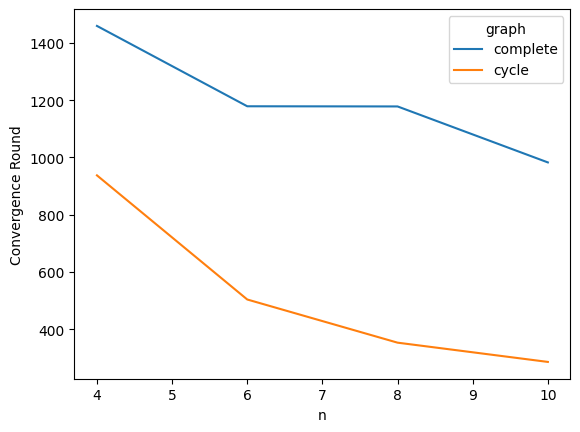

In [2]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results_BS = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=10000
)

batch_run_results_df_BS = pd.DataFrame(batch_run_results_BS)

g = sns.lineplot(data=batch_run_results_df_BS, x="n", y="Convergence Round", hue="graph", errorbar=None)

In this second model (CI), we add to the BS the critical interaction factor and see how it affects the results.

  0%|          | 0/8000 [00:00<?, ?it/s]

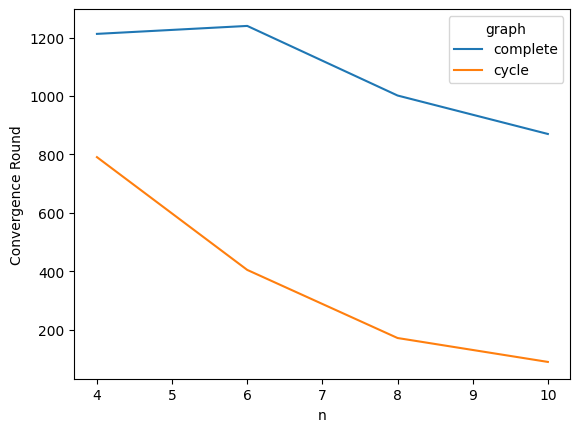

In [3]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : True,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results_CI = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=10000
)

batch_run_results_df_CI = pd.DataFrame(batch_run_results_CI)

g = sns.lineplot(data=batch_run_results_df_CI, x="n", y="Convergence Round", hue="graph", errorbar=None)


In this third model (IN) we add to the BS the rational inertia, and see how it affects the results

  0%|          | 0/8000 [00:00<?, ?it/s]

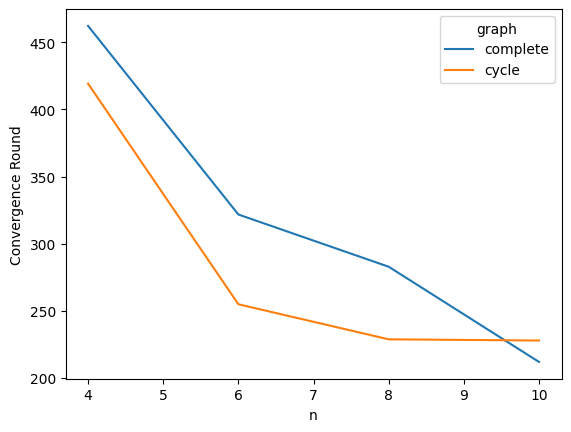

In [4]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : False,
        "inertia" : 10,
        "seed" : None
    }

batch_run_results_IN = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=10000
)

batch_run_results_df_IN = pd.DataFrame(batch_run_results_IN)

g = sns.lineplot(data=batch_run_results_df_IN, x="n", y="Convergence Round", hue="graph", errorbar=None)


In this model (CI, IN) both inertia and critical interaction are addedd to the BS

  0%|          | 0/8000 [00:00<?, ?it/s]

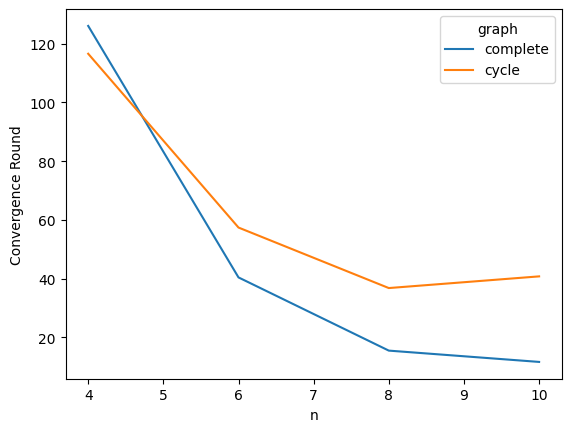

In [5]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : True,
        "inertia" : 10,
        "seed" : None
    }

batch_run_results_CI_IN = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=10000
)

batch_run_results_df_CI_IN = pd.DataFrame(batch_run_results_CI_IN)

g = sns.lineplot(data=batch_run_results_df_CI_IN, x="n", y="Convergence Round", hue="graph", errorbar=None)


In this model (TT), we add a theory threshold to the basic setup.

In [6]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : True,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results_TT = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=50000
)

batch_run_results_df_TT = pd.DataFrame(batch_run_results_TT)


  0%|          | 0/8000 [00:00<?, ?it/s]

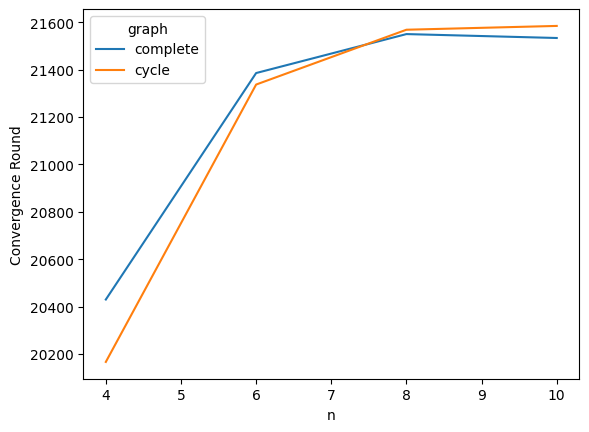

In [7]:

g = sns.lineplot(data=batch_run_results_df_TT, x="n", y="Convergence Round", hue="graph", errorbar=None)


The following model (TT, CI) adds both a theory threshold and crtical interaction to the basic setup

In [8]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : True,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : True,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results_TT_CI = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=10000
)

batch_run_results_df_TT_CI = pd.DataFrame(batch_run_results_TT_CI)


  0%|          | 0/8000 [00:00<?, ?it/s]

Due to the limited amount of steps for which the model was runned, we check how many iterations failed to reach consensus in 10000 rounds

In [9]:

excluded = batch_run_results_df_TT_CI[batch_run_results_df_TT_CI["Convergence Round"] == "No consensus"]
excluded


,RunId,iteration,Step,n,a_objective,b_objective,max_priors,graph,theory_threshold,step_pulls,dynamic,criticism,inertia,seed,Convergence Round,Correct Convergence
2792,2792,349,10000,4,0.5,0.499,4,complete,True,1000,True,True,0,None,No consensus,False
4825,4825,603,10000,4,0.5,0.499,4,cycle,True,1000,True,True,0,None,No consensus,False
5737,5737,717,10000,4,0.5,0.499,4,cycle,True,1000,True,True,0,None,No consensus,False


These iterations would have skewed the results of a 4 people cycle and complete graph towards an higher mean. However, given their limited number, we proceed to exclude them and plot the results.

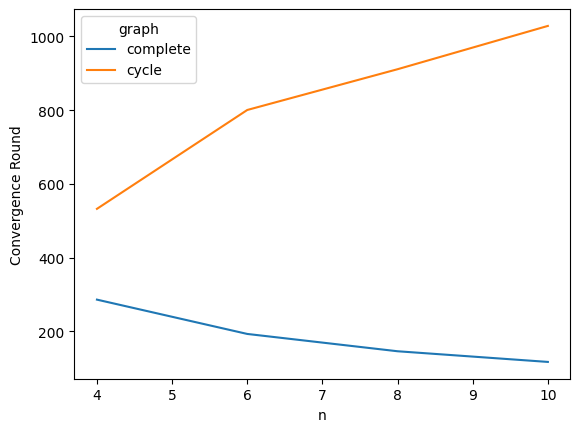

In [10]:

batch_run_results_df_TT_CI = batch_run_results_df_TT_CI[batch_run_results_df_TT_CI["Convergence Round"] != "No consensus"]

g = sns.lineplot(data=batch_run_results_df_TT_CI, x="n", y="Convergence Round", hue="graph", errorbar=None)


This last model presents all the features combined.

In [11]:

parameters_batch_run = {
        "n" : range(4, 11, 2),
        "a_objective" : .5, 
        "b_objective" : .499, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : True,
        "step_pulls" : 1000,
        "dynamic" : True,
        "criticism" : True,
        "inertia" : 10,
        "seed" : None
    }

batch_run_results_all = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=10000
)

batch_run_results_df_all = pd.DataFrame(batch_run_results_all)


  0%|          | 0/8000 [00:00<?, ?it/s]

Due to the limited amount of steps for which the model was runned, we check how many iterations failed to reach consensus in 10000 rounds

In [12]:
excluded = batch_run_results_df_all[batch_run_results_df_all["Convergence Round"] == "No consensus"]
excluded

,RunId,iteration,Step,n,a_objective,b_objective,max_priors,graph,theory_threshold,step_pulls,dynamic,criticism,inertia,seed,Convergence Round,Correct Convergence
1857,1857,232,10000,4,0.5,0.499,4,cycle,True,1000,True,True,10,None,No consensus,False
4800,4800,600,10000,4,0.5,0.499,4,complete,True,1000,True,True,10,None,No consensus,False


Again, given their limited number, we proceed to exclude them and plot the results

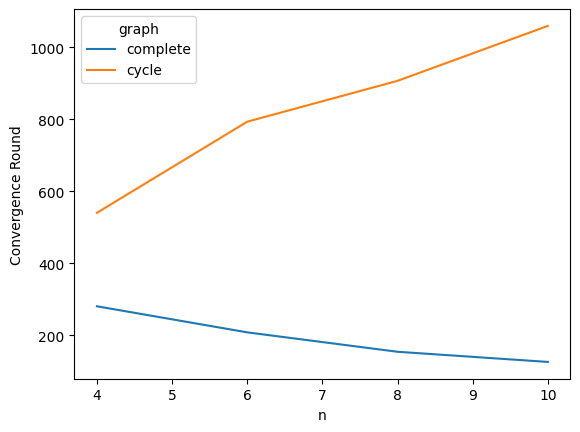

In [13]:
batch_run_results_df_all = batch_run_results_df_all[batch_run_results_df_all["Convergence Round"] != "No consensus"]

g = sns.lineplot(data=batch_run_results_df_all, x="n", y="Convergence Round", hue="graph", errorbar=None)


finally we see how the two network performed in all the different steups, excluding TT

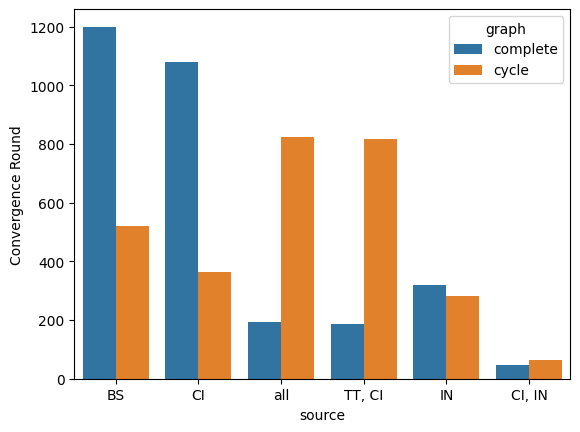

In [16]:
final_df = pd.concat(
    {
        "BS" : batch_run_results_df_BS, 
        "CI" : batch_run_results_df_CI,
        "all" : batch_run_results_df_all,
        "TT, CI" : batch_run_results_df_TT_CI,
        "IN" : batch_run_results_df_IN, 
        "CI, IN": batch_run_results_df_CI_IN
        
        
    }, names=["source"]).reset_index(level="source")

g = sns.barplot(data=final_df, x="source", y="Convergence Round", hue="graph", errorbar=None)


Overall, the results obtained show how in different settings the two graph perform differently, proving the main point.